# 2. Vortex coronagraph

Drop a `vortex` coronagraph into the chain. The reference PSF used for Strehl normalization is always generated with the coronagraph bypassed (matches the legacy convention). This tutorial loads the fixture config that reproduces the original VortexCoronagraph(2) setup against a Keck aperture (HCIPy built-in).

psf shape: (64, 64)  peak/min: 1.0 3.96912720616766e-06
pupil_opd RMS (nm): 0.0


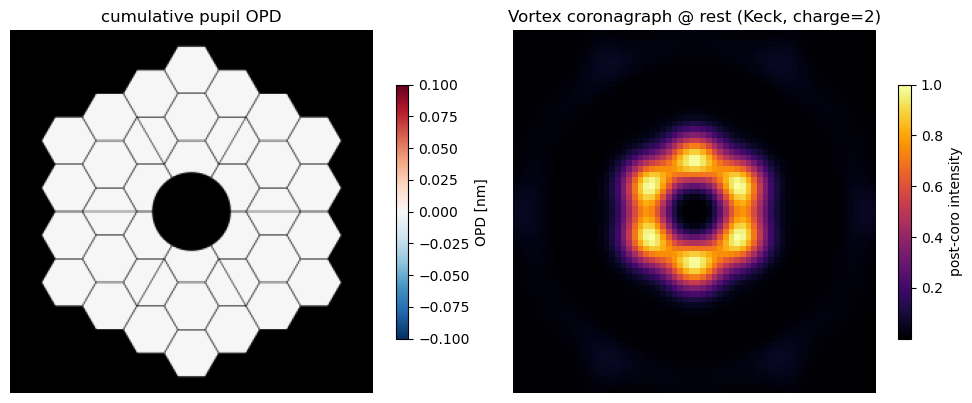

In [1]:
import hcipy
import numpy as np
import matplotlib.pyplot as plt
from telescope_sim import TelescopeSim

sim = TelescopeSim.from_yaml("fixtures/configs/07_coro_original.yaml")
out = sim.sample(meas_pupil_opd=True)
psf = out["images"]["psf"][..., 0]
print("psf shape:", psf.shape, " peak/min:", psf.max(), psf.min())
print('pupil_opd RMS (nm):', 1e9 * out['pupil_opd'].std())

# Pupil OPD (left) is ~0 at rest — Keck aperture transmits perfectly
# in-band. Even so, the coronagraph nulls the on-axis PSF (right).
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
opd_nm = hcipy.Field(
    1e9 * np.asarray(out['pupil_opd']), out['pupil_opd'].grid
)
plt.sca(axes[0])
im0 = hcipy.imshow_field(
    opd_nm, mask=sim.aperture.field, cmap='RdBu_r'
)
axes[0].set_title('cumulative pupil OPD')
axes[0].set_axis_off()
fig.colorbar(im0, ax=axes[0], shrink=0.7, label='OPD [nm]')
im1 = axes[1].imshow(psf, cmap='inferno')
axes[1].set_title('Vortex coronagraph @ rest (Keck, charge=2)')
axes[1].set_axis_off()
fig.colorbar(im1, ax=axes[1], shrink=0.7, label='post-coro intensity')
plt.tight_layout()
plt.show()
